**Import packages and dependecies**

In [1]:
%pip install -q -e ..

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from fda.basis import BSplineBasis
from fda.registration import (
    powerWarp,
    mobiusWarp,
    ramsayWarp,
    curveRegistration,
    GroupwiseCurveRegistration,
)

warnings.filterwarnings("ignore")

### I. Comparing Different Warping Methods h(t)

**Example 1: Power Warping Method**

In [ ]:
# Set up parameters
domain = (0, 50)
t_grid = np.linspace(domain[0], domain[1], 10)

# Initialize warper function (i.e. h(t))
warper = powerWarp(t_grid)

# Define list of different possible gamma values to apply to powerWarp 
gamma_list = [0.1, 0.4, 0.6, 0.8, 1.0, 2.0, 3.0]

# Create plot showing how different gamma values affect the way t gets warped
fig, ax = plt.subplots(figsize=(12,5))
for ind, gamma in enumerate(gamma_list):

    # Plot warped t values
    warped_t = warper.warp(gamma=gamma)

    ax.plot(
        t_grid,
        warped_t,
        linewidth=2,
        label=f"gamma={gamma:.2f}",
        color=plt.cm.get_cmap("Set3", len(gamma_list))(ind)
    )

    # Apply formatting
    ax.set_title(
        f"Warped h(t): Power Method", 
        fontsize=10, 
        fontweight="bold", 
        pad=10
    )
    ax.set_xlabel("Original $t$ values", fontsize=9)
    ax.set_ylabel(r"$h(t)$", fontsize=9)
    ax.set_ylim(domain[0]-1, domain[1]+1)
    ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, linestyle='--', alpha=0.7)
    
# Display the plot
plt.tight_layout()
plt.show()

**Example 2: Moebius Warping Method**

In [ ]:
# Set up parameters
domain = (0, 50)
t_grid = np.linspace(domain[0], domain[1], 10)

# Initialize warper function (i.e. h(t))
warper = mobiusWarp(t_grid)

# Define list of different possible f values to apply to mobiusWarp 
f_list = [-0.8, -0.5, -0.1, 0.0, 0.2, 0.5, 0.8, 1.0]

# Create plot showing how different f values affect the way t gets warped
fig, ax = plt.subplots(figsize=(12,5))
for ind, f in enumerate(f_list):

    # Plot warped t values
    warped_t = warper.warp(f=f)

    ax.plot(
        t_grid,
        warped_t,
        linewidth=2,
        label=f"f={f:.2f}",
        color=plt.cm.get_cmap("Set3", len(f_list))(ind)
    )

    # Apply formatting
    ax.set_title(
        f"Warped h(t): Mobius Method", 
        fontsize=10, 
        fontweight="bold", 
        pad=10
    )
    ax.set_xlabel("Original $t$ values", fontsize=9)
    ax.set_ylabel(r"$h(t)$", fontsize=9)
    ax.set_ylim(domain[0]-1, domain[1]+1)
    ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, linestyle='--', alpha=0.7)
    
# Display the plot
plt.tight_layout()
plt.show()

**Example 3: Ramsay Warping Method**

In [ ]:
# Set up parameters
domain = (0, 50)
t_grid = np.linspace(domain[0], domain[1], 10)
basis_object = BSplineBasis(
    domain_range=domain,
    n_basis=3,
    degree=2
)

# Initialize warper function (i.e. h(t))
warper = ramsayWarp(t_grid, basis_object)

# Define list of different possible coefficient values to apply to ramsayWarp 
# The number of coefficients need to match the number of basis (n_basis)
coefficients_list = [
    [0.5, 0.2, 3.0],
    [1.2, 0.8, 1.5],
    [0.1, 0.1, 8.0],
    [-0.4, 5.0, -1.3]
]


# Create plot showing how different f values affect the way t gets warped
fig, ax = plt.subplots(figsize=(12,5))
for ind, coefficents in enumerate(coefficients_list):

    # Plot warped t values
    warped_t = warper.warp(coefficients=coefficents)

    ax.plot(
        t_grid,
        warped_t,
        linewidth=2,
        label=f"coefs={coefficents}",
        color=plt.cm.get_cmap("Set3", len(coefficients_list))(ind)
    )

    # Apply formatting
    ax.set_title(
        f"Warped h(t): Ramsay Method", 
        fontsize=10, 
        fontweight="bold", 
        pad=10
    )
    ax.set_xlabel("Original $t$ values", fontsize=9)
    ax.set_ylabel(r"$h(t)$", fontsize=9)
    ax.set_ylim(domain[0]-1, domain[1]+1)
    ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, linestyle='--', alpha=0.7)
    
# Display the plot
plt.tight_layout()
plt.show()

### II. Optimizing Curve Registration or Alignment - Single Curve

**Comparing Optimized REGSSE Performance Under Different Warping Methods:**

In [ ]:
# -------------------------------------------------------------------------------------------------------------------------------------
# 1. DEFINE DATA AND PARAMETERS
# -------------------------------------------------------------------------------------------------------------------------------------

# Set up parameters
domain = (0, 100)
t_grid = np.linspace(domain[0], domain[1], 150)

# Define x(t)
x_basis = BSplineBasis(
    domain_range=domain,
    n_basis=6,
    degree=3
)
x_signal = np.exp(-0.5 * ((t_grid - 30) / 10) ** 2)
x_coefs = np.linalg.lstsq(x_basis.evaluate(t_grid), x_signal, rcond=None)[0]

# Basis object if using Ramsay method for setting h(t)
ramsay_basis = BSplineBasis(
    domain_range=domain,
    n_basis=4,
    degree=3
)

# Target curve that we want to align x(t) towards
target_basis = BSplineBasis(
    domain_range=domain,
    n_basis=6,
    degree=3
)
target_signal = np.exp(-0.5 * ((t_grid - 70) / 10) ** 2)
target_coefs = np.linalg.lstsq(target_basis.evaluate(t_grid), target_signal, rcond=None)[0]

# -------------------------------------------------------------------------------------------------------------------------------------
# 2. CURVE ALIGNMENT OPTIMIZATION (NO REGULARIZATION APPLIED)
# -------------------------------------------------------------------------------------------------------------------------------------

# Initialize curve registration
curve_registration_power = curveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs=x_coefs,
    target_basis=target_basis,
    target_coefs=target_coefs,
    warping_method="power",
    ramsay_basis=ramsay_basis
)

curve_registration_mobius = curveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs=x_coefs,
    target_basis=target_basis,
    target_coefs=target_coefs,
    warping_method="mobius",
    ramsay_basis=ramsay_basis
)

curve_registration_ramsay = curveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs=x_coefs,
    target_basis=target_basis,
    target_coefs=target_coefs,
    warping_method="ramsay",
    ramsay_basis=ramsay_basis
)


# Retrieve the REGSSE after optimization
optimization_results_power = curve_registration_power.optimize(initial_guess=None, optimization_method="L-BFGS-B")
optimization_results_mobius = curve_registration_mobius.optimize(initial_guess=None, optimization_method="L-BFGS-B")
optimization_results_ramsay = curve_registration_ramsay.optimize(initial_guess=None, optimization_method="L-BFGS-B")

# -------------------------------------------------------------------------------------------------------------------------------------
# 3. CURVE ALIGNMENT OPTIMIZATION (W/ REGULARIZATION APPLIED)
# -------------------------------------------------------------------------------------------------------------------------------------

# Initialize curve registration (with regularization)
curve_registration_power_reg = curveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs=x_coefs,
    target_basis=target_basis,
    target_coefs=target_coefs,
    warping_method="power",
    ramsay_basis=ramsay_basis,
    lam=1e-4
)

curve_registration_mobius_reg = curveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs=x_coefs,
    target_basis=target_basis,
    target_coefs=target_coefs,
    warping_method="mobius",
    ramsay_basis=ramsay_basis,
    lam=1e-4
)

curve_registration_ramsay_reg = curveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs=x_coefs,
    target_basis=target_basis,
    target_coefs=target_coefs,
    warping_method="ramsay",
    ramsay_basis=ramsay_basis,
    lam=1e-4
)

# Retrieve the REGSSE after optimization
optimization_results_power_reg = curve_registration_power_reg.optimize(initial_guess=None, optimization_method="L-BFGS-B")
optimization_results_mobius_reg = curve_registration_mobius_reg.optimize(initial_guess=None, optimization_method="L-BFGS-B")
optimization_results_ramsay_reg = curve_registration_ramsay_reg.optimize(initial_guess=None, optimization_method="L-BFGS-B")

# -------------------------------------------------------------------------------------------------------------------------------------
# 4. SHOW RESULTS
# -------------------------------------------------------------------------------------------------------------------------------------

all_optimization_results = {
    "power - no regularization": optimization_results_power,
    "mobius - no regularization": optimization_results_mobius,
    "ramsay - no regularization": optimization_results_ramsay,
    "power - w/ regularization": optimization_results_power_reg,
    "mobius - w/ regularization": optimization_results_mobius_reg,
    "ramsay - w/ regularization": optimization_results_ramsay_reg
}

for warping_method, optimization_results in all_optimization_results.items():
    succeeded = optimization_results.success
    best_params = optimization_results.x
    regsse = optimization_results.fun

    print(f"\nWarping Method: {warping_method.upper()}")
    print("-"*100)
    print(f"Optimization Succeeded: {succeeded}")
    print(f"Optimized Parameters:   {np.round(best_params, 4)}")
    print(f"Minimized REGSSE:       {regsse:.6f}")


**Create Plot of Curve Alignment for Each Warping Method (No Regularization Applied)**

In [ ]:
# 1. Setup the figure layout (3 columns: Original vs Target, Warping Functions, Registered Curves)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False)
colors = {"power": "#1f77b4", "mobius": "#ff7f0e", "ramsay": "#2ca02c"}

# Evaluate the unwarped reference profiles
# h(t) = t baseline (Initial identity line)
t_baseline = t_grid 
x_original = curve_registration_power.x_basis.evaluate(t_baseline) @ curve_registration_power.x_coefs
mu_target = curve_registration_power.target_basis.evaluate(t_baseline) @ curve_registration_power.target_coefs

# -------------------------------------------------------------
# PANEL 1: Unaligned Baseline
# -------------------------------------------------------------
axes[0].plot(t_grid, x_original, label="Original Curve $x(t)$", color="black", linewidth=2.5)
axes[0].plot(t_grid, mu_target, label="Target Template $\mu(t)$", color="red", linestyle="--", linewidth=2)
axes[0].set_title("Before Registration (Phase Misalignment)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Time ($t$)")
axes[0].set_ylabel("Functional Value")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Place Legend 1 below the subplot
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# -------------------------------------------------------------
# PANELS 2 & 3: Loop Through Each Warping Framework to Compare
# -------------------------------------------------------------
# Plot the identity line h(t) = t on the warping panel as a baseline reference
axes[1].plot(t_grid, t_grid, color="black", linestyle=":", alpha=0.7, label="Identity $h(t)=t$")

# Mapping our registration objects and their corresponding optimizer results
registration_models = {
    "power": (curve_registration_power, optimization_results_power),
    "mobius": (curve_registration_mobius, optimization_results_mobius),
    "ramsay": (curve_registration_ramsay, optimization_results_ramsay),
}

for method, (model, result) in registration_models.items():
    if result.success:
        # Extract the optimized parameters
        best_params = result.x
        
        # Track and build the warped timeline h(t) using the internal method mapping
        h_t_optimized = model._warping_function(best_params)
        h_t_optimized = np.clip(h_t_optimized, model.t_min, model.t_max)
        
        # Evaluate the registered curve: x_registered(t) = x(h(t))
        x_registered = model.x_basis.evaluate(h_t_optimized) @ model.x_coefs
        
        # Plot the warping function h(t) vs t
        axes[1].plot(t_grid, h_t_optimized, label=f"{method.upper()} Warp", color=colors[method], linewidth=2)
        
        # Plot the newly aligned functional curve profile
        axes[2].plot(t_grid, x_registered, label=f"Aligned via {method.upper()}", color=colors[method], linewidth=2)

# Format Warping Function Panel
axes[1].set_title("Warping Functions $h(t)$", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Original Time ($t$)")
axes[1].set_ylabel("Warped Time ($h(t)$)")
axes[1].grid(True, linestyle=":", alpha=0.6)

# Place Legend 2 below the subplot
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# Format Registered Curve Panel
axes[2].plot(t_grid, mu_target, color="red", linestyle="--", linewidth=2, label="Target Template $\mu(t)$")
axes[2].set_title("After Registration (Aligned Curves)", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Time ($t$)")
axes[2].grid(True, linestyle=":", alpha=0.6)

# Place Legend 3 below the subplot
axes[2].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# Adjust layout bounding box to accommodate the bottom legends gracefully
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

**Create Plot of Curve Alignment for Each Warping Method (w/ Regularization Applied)**

In [ ]:

# 1. Setup the figure layout (3 columns: Original vs Target, Warping Functions, Registered Curves)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False)
colors = {"power": "#1f77b4", "mobius": "#ff7f0e", "ramsay": "#2ca02c"}

# -------------------------------------------------------------
# PANEL 1: Unaligned Baseline
# -------------------------------------------------------------
axes[0].plot(t_grid, x_original, label="Original Curve $x(t)$", color="black", linewidth=2.5)
axes[0].plot(t_grid, mu_target, label="Target Template $\mu(t)$", color="red", linestyle="--", linewidth=2)
axes[0].set_title("Before Registration (Phase Misalignment)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Time ($t$)")
axes[0].set_ylabel("Functional Value")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Place Legend 1 below the subplot
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# -------------------------------------------------------------
# PANELS 2 & 3: Loop Through Each Warping Framework to Compare
# -------------------------------------------------------------
# Plot the identity line h(t) = t on the warping panel as a baseline reference
axes[1].plot(t_grid, t_grid, color="black", linestyle=":", alpha=0.7, label="Identity $h(t)=t$")

# Mapping our registration objects and their corresponding optimizer results
registration_models = {
    "power": (curve_registration_power_reg, optimization_results_power_reg),
    "mobius": (curve_registration_mobius_reg, optimization_results_mobius_reg),
    "ramsay": (curve_registration_ramsay_reg, optimization_results_ramsay_reg),
}

for method, (model, result) in registration_models.items():
    if result.success:
        # Extract the optimized parameters
        best_params = result.x
        
        # Track and build the warped timeline h(t) using the internal method mapping
        h_t_optimized = model._warping_function(best_params)
        h_t_optimized = np.clip(h_t_optimized, model.t_min, model.t_max)
        
        # Evaluate the registered curve: x_registered(t) = x(h(t))
        x_registered = model.x_basis.evaluate(h_t_optimized) @ model.x_coefs
        
        # Plot the warping function h(t) vs t
        axes[1].plot(t_grid, h_t_optimized, label=f"{method.upper()} Warp", color=colors[method], linewidth=2)
        
        # Plot the newly aligned functional curve profile
        axes[2].plot(t_grid, x_registered, label=f"Aligned via {method.upper()}", color=colors[method], linewidth=2)

# Format Warping Function Panel
axes[1].set_title("Warping Functions $h(t)$", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Original Time ($t$)")
axes[1].set_ylabel("Warped Time ($h(t)$)")
axes[1].grid(True, linestyle=":", alpha=0.6)

# Place Legend 2 below the subplot
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# Format Registered Curve Panel
axes[2].plot(t_grid, mu_target, color="red", linestyle="--", linewidth=2, label="Target Template $\mu(t)$")
axes[2].set_title("After Registration (Aligned Curves)", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Time ($t$)")
axes[2].grid(True, linestyle=":", alpha=0.6)

# Place Legend 3 below the subplot
axes[2].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# Adjust layout bounding box to accommodate the bottom legends gracefully
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()


### III. Optimizing Groupwise Registrations or Alignments 

**Align a Group of Curves Amongst Themselves**

In [3]:
# 1. High density grid structure
domain = (0, 100)
t_grid = np.linspace(domain[0], domain[1], 150)
x_basis = BSplineBasis(domain_range=domain, n_basis=6, degree=3)
ramsay_basis = BSplineBasis(domain_range=domain, n_basis=4, degree=3)
warping_method = "ramsay"

# 2. Create 3 separate sample curves with staggered features (Phase variance)
curve_1_coefs = [0.1, 12.0, 4.0, 0.1, 0.1, 0.1]  # Early peak
curve_2_coefs = [0.1, 0.1, 12.0, 4.0, 0.1, 0.1]  # Mid peak
curve_3_coefs = [0.1, 0.1, 0.1, 12.0, 4.0, 0.1]  # Late peak

# Stack them horizontally into a 2D matrix shape: (3, 6)
population_coefs_matrix = np.vstack([curve_1_coefs, curve_2_coefs, curve_3_coefs])

# 3. Instantiate and run groupwise registration
group_registration = GroupwiseCurveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs_matrix=population_coefs_matrix,
    warping_method=warping_method,
    ramsay_basis=ramsay_basis,
    lam=1e-4
)

optimization_results = group_registration.optimize()
succeeded = optimization_results.success
best_params = optimization_results.x_matrix
regsse = optimization_results.fun

print(f"\nWarping Method: {warping_method.upper()}")
print("-"*100)
print(f"Optimization Succeeded: {succeeded}")
print(f"Optimized Parameters:   \n{np.round(best_params, 4)}")
print(f"Minimized REGSSE: {regsse:.6f}")


Warping Method: RAMSAY
----------------------------------------------------------------------------------------------------
Optimization Succeeded: True
Optimized Parameters:   
[[-269.7376  210.0819    2.9535   56.6013]
 [ -19.4605  -10.0825  106.1406  -76.6217]
 [  24.9077  -45.6889  141.8076 -120.8671]]
Minimized REGSSE: 0.206307


**Plot the Group of Curves Pre- and Post- Alignment Optimization**

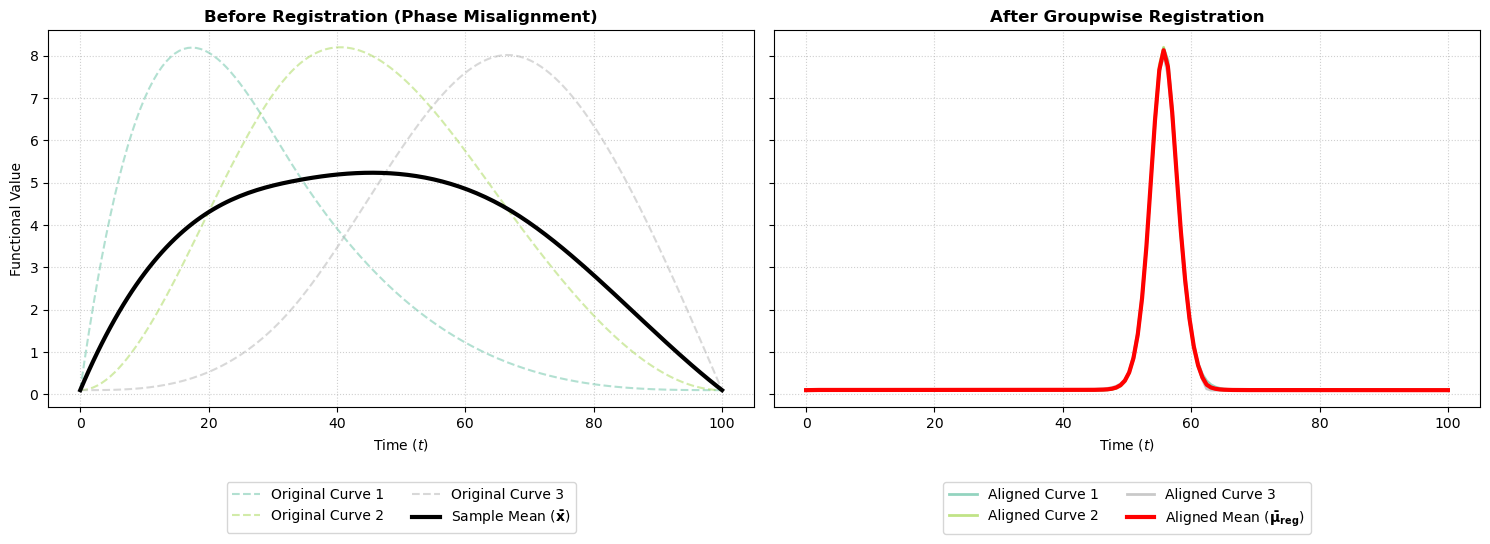

In [5]:
# 1. Initialize arrays to hold the functional values over time
n_curves = group_registration.n_curves
t_grid = group_registration.t_grid

original_curves = np.zeros((len(t_grid), n_curves))
aligned_curves = np.zeros((len(t_grid), n_curves))

# 2. Reconstruct the curves using the optimized parameter matrix
# optimization_results.x_matrix has shape (n_curves, n_parameters_per_curve)
optimized_param_matrix = optimization_results.x_matrix

for i in range(n_curves):
    # Reconstruct the original curve (unwarped, using identity h(t) = t)
    original_curves[:, i] = group_registration.x_basis.evaluate(t_grid) @ group_registration.x_coefs_matrix[i, :]
    
    # Retrieve the specific warping parameters optimized for this curve
    curve_params = optimized_param_matrix[i, :]
    
    # Generate the warped timeline h_i(t)
    h_t_optimized = group_registration.warping_objects[i](curve_params)
    h_t_optimized = np.clip(h_t_optimized, t_grid[0], t_grid[-1])
    
    # Evaluate the registered curve: x_i(h_i(t))
    aligned_curves[:, i] = group_registration.x_basis.evaluate(h_t_optimized) @ group_registration.x_coefs_matrix[i, :]

# 3. Calculate population means
initial_mean = np.mean(original_curves, axis=1)
aligned_mean = np.mean(aligned_curves, axis=1)

# 4. Set up the visualization canvas (2 Subplots side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
distinct_colors = plt.cm.get_cmap("Set2", n_curves)

# -------------------------------------------------------------
# LEFT PANEL: Before Registration (Raw Phase Variance)
# -------------------------------------------------------------
for i in range(n_curves):
    axes[0].plot(t_grid, original_curves[:, i], color=distinct_colors(i), alpha=0.5, 
                 linestyle="--", label=f"Original Curve {i+1}")
# Overlay the cross-sectional mean before alignment
axes[0].plot(t_grid, initial_mean, color="black", linewidth=3, label="Sample Mean ($\mathbf{\\bar{x}}$)")

axes[0].set_title("Before Registration (Phase Misalignment)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Time ($t$)", fontsize=10)
axes[0].set_ylabel("Functional Value", fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# -------------------------------------------------------------
# RIGHT PANEL: After Registration (Groupwise Amplitude Convergence)
# -------------------------------------------------------------
for i in range(n_curves):
    # FIX: Define the label string on its own line before passing it to plot()
    curve_label = f"Aligned Curve {i+1}"
    axes[1].plot(t_grid, aligned_curves[:, i], color=distinct_colors(i), alpha=0.7, 
                 linewidth=2, label=curve_label)
                 
# Overlay the sharp group population mean after alignment
axes[1].plot(t_grid, aligned_mean, color="red", linewidth=3, label="Aligned Mean ($\mathbf{\\bar{\mu}_{reg}}$)")

axes[1].set_title("After Groupwise Registration", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Time ($t$)", fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# Adjust layout bounding box to clean up bottom space for external legends
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()